In [1]:
pip install pandas numpy scikit-learn matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
data = pd.read_csv("exams.csv")

print(data.head())

   gender race/ethnicity parental level of education         lunch  \
0    male        group A                 high school      standard   
1  female        group D            some high school  free/reduced   
2    male        group E                some college  free/reduced   
3    male        group B                 high school      standard   
4    male        group E          associate's degree      standard   

  test preparation course  math score  reading score  writing score  
0               completed          67             67             63  
1                    none          40             59             55  
2                    none          59             60             50  
3                    none          77             78             68  
4               completed          78             73             68  


In [4]:
data = pd.get_dummies(data)

print(data.head())

   math score  reading score  writing score  gender_female  gender_male  \
0          67             67             63          False         True   
1          40             59             55           True        False   
2          59             60             50          False         True   
3          77             78             68          False         True   
4          78             73             68          False         True   

   race/ethnicity_group A  race/ethnicity_group B  race/ethnicity_group C  \
0                    True                   False                   False   
1                   False                   False                   False   
2                   False                   False                   False   
3                   False                    True                   False   
4                   False                   False                   False   

   race/ethnicity_group D  race/ethnicity_group E  \
0                   False        

In [5]:
X = data.drop("math score", axis=1)

In [6]:
feature_columns = X.columns

In [7]:
X = data.drop("math score", axis=1)
y = data["math score"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [10]:
lr_mse = mean_squared_error(y_test, lr_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
rf_mse = mean_squared_error(y_test, rf_pred)

lr_r2 = r2_score(y_test, lr_pred)
dt_r2 = r2_score(y_test, dt_pred)
rf_r2 = r2_score(y_test, rf_pred)

In [11]:
print("Model Performance:\n")

print("Linear Regression")
print("MSE:", lr_mse)
print("R2 Score:", lr_r2)
print()

print("Decision Tree")
print("MSE:", dt_mse)
print("R2 Score:", dt_r2)
print()

print("Random Forest")
print("MSE:", rf_mse)
print("R2 Score:", rf_r2)

Model Performance:

Linear Regression
MSE: 30.281717975930796
R2 Score: 0.8706228922498696

Decision Tree
MSE: 71.54
R2 Score: 0.694348970035283

Random Forest
MSE: 35.82498252375
R2 Score: 0.8469395749671208


In [12]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MSE": [lr_mse, dt_mse, rf_mse],
    "R2 Score": [lr_r2, dt_r2, rf_r2]
})

print(model_comparison)

               Model        MSE  R2 Score
0  Linear Regression  30.281718  0.870623
1      Decision Tree  71.540000  0.694349
2      Random Forest  35.824983  0.846940


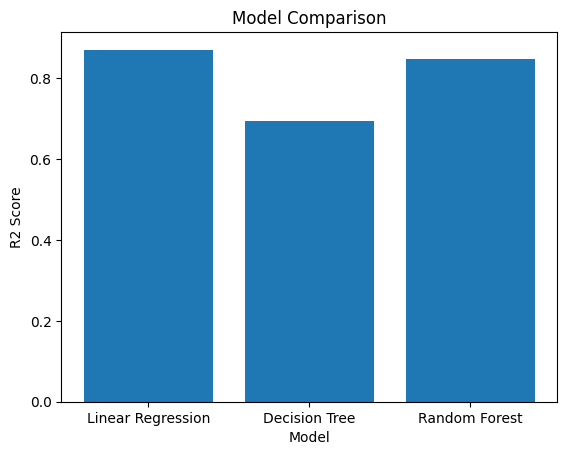

In [13]:
plt.bar(model_comparison["Model"], model_comparison["R2 Score"])
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

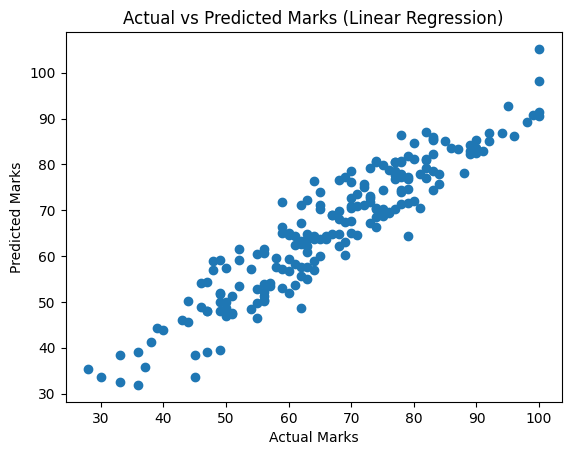

In [14]:
plt.scatter(y_test, lr_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks (Linear Regression)")
plt.show()

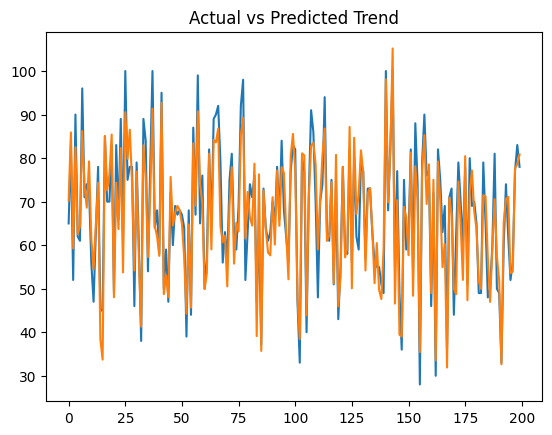

In [15]:
plt.plot(y_test.values)
plt.plot(lr_pred)
plt.title("Actual vs Predicted Trend")
plt.show()

In [16]:
new_student = X.iloc[0:1]
predicted_mark = lr.predict(new_student)

print("Predicted Math Score:", predicted_mark[0])

Predicted Math Score: 67.22644408154397


In [17]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(lr, f)

with open("features.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

In [18]:
from google.colab import files
files.download("student_marks_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>